In [29]:
import pandas as pd

paid_df = pd.read_csv("data/new-model-training-data/merged_claims.csv")

/tmp/ipykernel_1897464/713406992.py:3: DtypeWarning: Columns (0,1,16,17,20,21,24,25,28,29,32,33,36,37,39,40,41,42,43,44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  paid_df = pd.read_csv("data/new-model-training-data/merged_claims.csv")


🔹 Null vs Non-Null Counts per Column:

               Null Values  Non-Null Values
GeneralRemark       355526             3595
Remark1             343086            16035
Remark2             351021             8100
Remark3             354208             4913
Remark4             356824             2297
Remark5             358112             1009
Remark6             358732              389


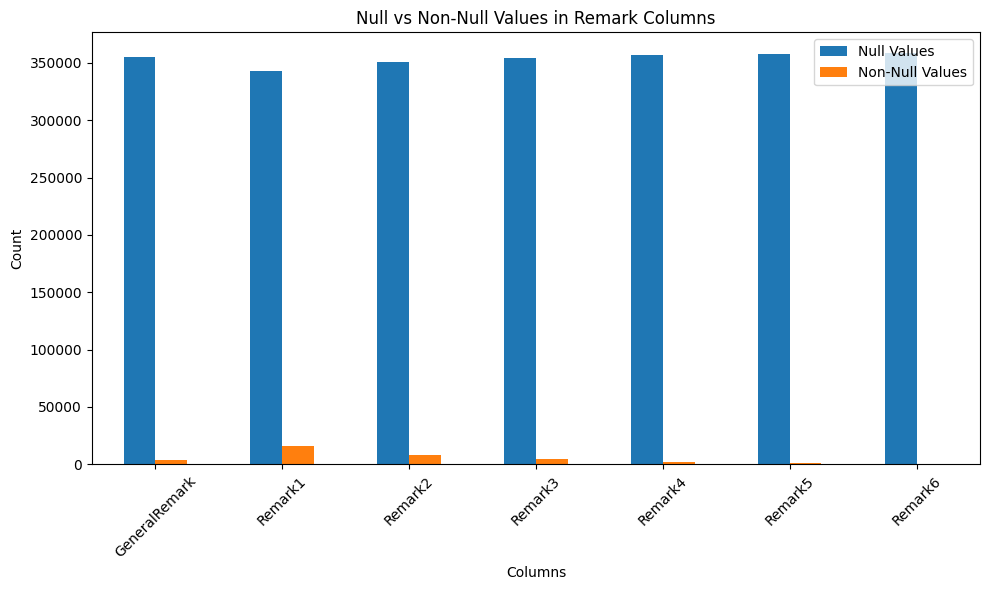

In [ ]:
import matplotlib.pyplot as plt


remark_columns = ["GeneralRemark"] + [f"Remark{i}" for i in range(1, 7)]

# Calculate null and non-null values
remark_stats = pd.DataFrame({
    "Null Values": paid_df[remark_columns].isnull().sum(),
    "Non-Null Values": paid_df[remark_columns].notnull().sum()
})

print("🔹 Null vs Non-Null Counts per Column:\n")
print(remark_stats)

# Plot visualization
remark_stats.plot(kind="bar", figsize=(10, 6))
plt.title("Null vs Non-Null Values in Remark Columns")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🔹 Unique Value Counts per Column:

               Unique Values
GeneralRemark           3021
Remark1                 1846
Remark2                 1108
Remark3                  739
Remark4                  474
Remark5                  281
Remark6                  141


<Figure size 1000x600 with 0 Axes>

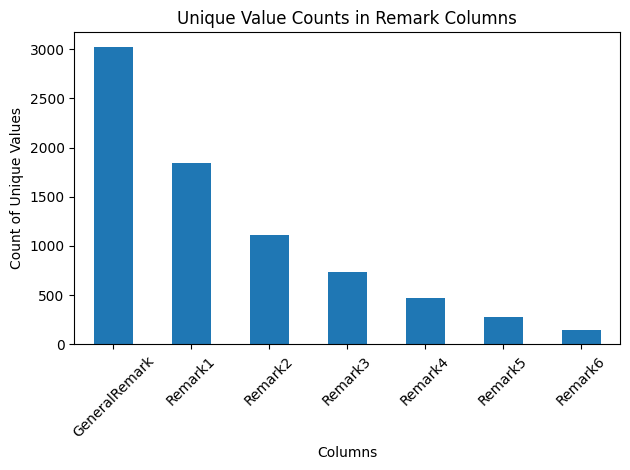

In [3]:
remark_columns = ["GeneralRemark"] + [f"Remark{i}" for i in range(1, 7)]

# Compute unique value counts for each column
unique_counts = paid_df[remark_columns].nunique(dropna=True)

# Create DataFrame for better readability
unique_df = pd.DataFrame({
    "Unique Values": unique_counts
}).sort_values(by="Unique Values", ascending=False)

print("🔹 Unique Value Counts per Column:\n")
print(unique_df)

# Plot graph
plt.figure(figsize=(10, 6))
unique_df.plot(kind="bar", legend=False)
plt.title("Unique Value Counts in Remark Columns")
plt.xlabel("Columns")
plt.ylabel("Count of Unique Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Select remark columns
remark_columns = ["GeneralRemark"] + [f"Remark{i}" for i in range(1, 7)]

# Extract rows where any of these columns have non-null data
remarks_exist_df = paid_df[paid_df[remark_columns].notnull().any(axis=1)]

# Save to new CSV file
remarks_exist_df.to_csv("all_remarks.csv", index=False)

print(" Saved rows with remarks to 'all_remarks.csv'")

 Saved rows with remarks to 'all_remarks.csv'


In [ ]:
paid_df = pd.read_csv("billingpaymentprediction/all_remarks.csv")

# Extract rows where GeneralRemark exists
general_remark_df = paid_df[paid_df["GeneralRemark"].notnull()]

# Save to new CSV file
general_remark_df.to_csv("general_remarks.csv", index=False)

print("Saved rows with GeneralRemark to 'general_remarks.csv'")


Saved rows with GeneralRemark to 'general_remarks.csv'


/tmp/ipykernel_1897464/2570882596.py:1: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  paid_df = pd.read_csv("/home/code/Desktop/billingpaymentprediction/all_remarks.csv")


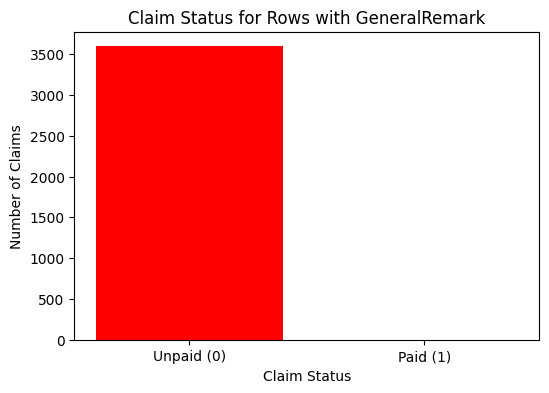

In [35]:
import matplotlib.pyplot as plt

# Count unpaid (0) and paid (1)
unpaid_count = (general_remark_df['Claim_status'] == 0).sum()
paid_count = (general_remark_df['Claim_status'] == 1).sum()

# Plot
plt.figure(figsize=(6,4))
plt.bar(['Unpaid (0)', 'Paid (1)'], [unpaid_count, paid_count], color=['red', 'green'])
plt.title("Claim Status for Rows with GeneralRemark")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")
plt.show()


In [32]:
# Filter rows where GeneralRemark is null and Claim_status is 1
paid_no_remark_df = paid_df[(paid_df["Claim_status"] == 1)]

# Take 500 rows
paid_no_remark_sample = paid_no_remark_df.head(500)

# Save to CSV if needed
paid_no_remark_sample.to_csv("paid_no_general_remarks.csv", index=False)

print("Saved 500 paid rows without GeneralRemark to 'paid_no_general_remarks.csv'")


Saved 500 paid rows without GeneralRemark to 'paid_no_general_remarks.csv'


In [33]:
paid_no_remark_sample

,InsuID,InsuPlanID,Diag1,Diag2,Diag3,Diag4,Diag5,Diag6,Diag7,Diag8,...,Paid6,Proc6_Adj,Claim_status,GeneralRemark,Remark1,Remark2,Remark3,Remark4,Remark5,Remark6
0,NaN,NaN,M54.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NY1652,H35.013,H52.4,NaN,NaN,NaN,NaN,NaN,NaN,...,Not Paid,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109.0,NaN,F10.10,K74.60,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109.0,NaN,I10,E03.9,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109.0,NaN,E11.9,E78.5,I10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,12.0,2,D51.8,C61,I10,I50.9,I48.0,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,12.0,2,D51.8,D51.1,F41.1,G43.909,H81.10,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,12.0,2,D51.8,D64.9,F41.1,R26.89,M48.061,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
498,12.0,2,D51.8,D64.9,M81.0,E11.9,I10,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Filter rows where GeneralRemark is null and Claim_status is 1
un_paid_no_remark_df = paid_df[(paid_df["GeneralRemark"].isnull()) & (paid_df["Claim_status"] == 0)]

# Take 500 rows
unpaid_no_remark_sample = un_paid_no_remark_df.head(500)

# Save to CSV if needed
unpaid_no_remark_sample.to_csv("unpaid_no_general_remarks.csv", index=False)

print("Saved 500 unpaid rows without GeneralRemark to 'unpaid_no_general_remarks.csv'")


Saved 500 unpaid rows without GeneralRemark to 'paid_no_general_remarks.csv'


In [37]:

import pandas as pd

# Concatenate the DataFrames
combined_df = pd.concat([general_remark_df, paid_no_remark_sample, unpaid_no_remark_sample], ignore_index=True)

# Optional: save to CSV
combined_df.to_csv("combined_claims.csv", index=False)

print("Concatenated DataFrame saved to 'combined_claims.csv'")


Concatenated DataFrame saved to 'combined_claims.csv'


In [38]:
combined_df

,InsuID,InsuPlanID,Diag1,Diag2,Diag3,Diag4,Diag5,Diag6,Diag7,Diag8,...,Paid6,Proc6_Adj,Claim_status,GeneralRemark,Remark1,Remark2,Remark3,Remark4,Remark5,Remark6
0,15,5,I73.9,I10,E11.42,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0,(F2) - Finalized/Denial-The claim/line has be...,NaN,NaN,NaN,NaN,NaN,NaN
1,15,5,I73.9,G90.09,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0,(F2) - Finalized/Denial-The claim/line has be...,NaN,NaN,NaN,NaN,NaN,NaN
2,15,5,I73.9,E78.5,G90.09,E11.9,NaN,NaN,NaN,NaN,...,0.0,NaN,0,(F2) - Finalized/Denial-The claim/line has be...,NaN,NaN,NaN,NaN,NaN,NaN
3,15,5,I73.9,E78.5,I10,G90.09,NaN,NaN,NaN,NaN,...,0.0,NaN,0,(F2) - Finalized/Denial-The claim/line has be...,NaN,NaN,NaN,NaN,NaN,NaN
4,NY1744,NY1652,H53.003,H53.023,H52.13,H52.223,NaN,NaN,NaN,NaN,...,0.0,NaN,0,9/6/2024 $18.00 $0.00 Finalized/Denia | Pend...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4590,13,3,E55.9,I10,R26.2,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0,NaN,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,NaN,NaN,NaN
4591,13,3,F60.5,F41.1,F33.0,F43.10,NaN,NaN,NaN,NaN,...,0.0,NaN,0,NaN,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,NaN,NaN,NaN,NaN,NaN
4592,13,3,I10,E11.8,E78.5,I25.10,NaN,NaN,NaN,NaN,...,0.0,NaN,0,NaN,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,NaN,NaN,NaN
4593,13,3,I25.10,E11.9,I48.91,I10,NaN,NaN,NaN,NaN,...,0.0,NaN,0,NaN,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,CO-13 : CONTRACTUAL OBLIGATION - The date of d...,NaN,NaN,NaN


In [ ]:
import pandas as pd

# Load combined_df if not already loaded
combined_df = pd.read_csv("billingpaymentprediction/remarks_embeddings/remarks-data/combined_claims.csv")  # optional

# Fill NaN with empty string first
combined_df["GeneralRemark"] = combined_df["GeneralRemark"].fillna("")

# Replace empty strings based on Claim_status
combined_df["GeneralRemark"] = combined_df.apply(
    lambda row: "Missing Remarks for unpaid" if row["Claim_status"] == 0 and row["GeneralRemark"].strip() == "" 
    else ("Missing Remarks for paid" if row["Claim_status"] == 1 and row["GeneralRemark"].strip() == "" else row["GeneralRemark"]),
    axis=1
)

# Save to new CSV
combined_df.to_csv("combined_df_filled_remarks.csv", index=False)
print("Updated combined DataFrame saved to 'combined_df_filled_remarks.csv'")

# Check
print(combined_df[["Claim_status", "GeneralRemark"]].head(10))


Updated combined DataFrame saved to 'combined_df_filled_remarks.csv'
   Claim_status                                      GeneralRemark
0             0   (F2) - Finalized/Denial-The claim/line has be...
1             0   (F2) - Finalized/Denial-The claim/line has be...
2             0   (F2) - Finalized/Denial-The claim/line has be...
3             0   (F2) - Finalized/Denial-The claim/line has be...
4             0   9/6/2024 $18.00 $0.00 Finalized/Denia |  Pend...
5             0   Client Code: 3034 Name: LOCAL 812 HEALTH FUND...
6             0   Clm Ref.#: AA1D1C00082FF87   Client Code: 394...
7             0   CO: Contractual Obligations-The diagnosis is ...
8             0   Impact Claim ID: A002L5KX Doc. Type: HCFA 150...
9             0   Impact Claim ID: A0033PN7 Doc. Type: HCFA 150...


In [ ]:
import pandas as pd

# Load the combined dataframe
new_combined_df = pd.read_csv("billingpaymentprediction/combined_df_filled_remarks.csv")

# Split into paid and unpaid based on Claim_status
paid_df = new_combined_df[new_combined_df["Claim_status"] == 1]
unpaid_df = new_combined_df[new_combined_df["Claim_status"] == 0]

# Save to separate CSV files
paid_df.to_csv("paid_remarks_final.csv", index=False)
unpaid_df.to_csv("unpaid_remarks_final.csv", index=False)

print(f"Saved {len(paid_df)} paid claims to 'paid_remarks_final.csv'")
print(f"Saved {len(unpaid_df)} unpaid claims to 'unpaid_remarks_final.csv'")


Saved 500 paid claims to 'paid_remarks_final.csv'
Saved 4095 unpaid claims to 'unpaid_remarks_final.csv'
